# Exploratory Data Analysis

In this notebook, we explore the Jaguar re-identification dataset. We use FiftyOne for visual inspection and examine various aspects of the dataset.

The analysis is structured as follows:
1. Image Quality Analysis: examining widths, heights, and masked pixels.
2. Identity Distribution of Jaguars: analyzing the number of images per individual.
3. Embedding Analysis: studying feature representations.
4. Duplicate Analysis: identifying potential duplicate images.

Through this exploration, we aim to gain initial insights that could inform experiments to improve upon the baseline approach.

## 1. Setup and Configuration

This section defines the required imports and configuration settings used throughout the notebook. These include library dependencies and any global parameters needed for the subsequent exploratory data analysis.

In [1]:
EXPERIMENT_NAME = "00_exploratory-data-analysis"
RANDOM_SEED = 51

# -----------------------------
# Environment setup
# -----------------------------
import os
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

# -----------------------------
# Standard library imports
# -----------------------------
from dotenv import load_dotenv
import glob
from pathlib import Path
import sys

# -----------------------------
# Third-party libraries
# -----------------------------
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import wandb

import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

import fiftyone as fo
import fiftyone.brain as fob
from fiftyone import ViewField as F

# -----------------------------
# Project path setup
# -----------------------------
PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

# -----------------------------
# Local modules
# -----------------------------
from src.datasets import ImageDataset
from src.utils import (
    get_device,
    set_seeds,
    get_embeddings,
)
from src.visualization import visualize_embeddings_mds

# -----------------------------
# Reproducibility
# -----------------------------
set_seeds(RANDOM_SEED)
print(f"PyTorch version: {torch.__version__}")

All random seeds set to 51 for reproducibility
PyTorch version: 2.9.1+cu128


Define shared paths for the whole project.

In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

In [3]:
# Configuration
config = {   
    # Model
    "megadescriptor_model": "hf-hub:BVRA/MegaDescriptor-L-384",
    "input_size": 384,
    "batch_size": 32,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  megadescriptor_model: hf-hub:BVRA/MegaDescriptor-L-384
  input_size: 384
  batch_size: 32
  seed: 51


In [4]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project=os.getenv("WANDB_PROJECT", "jaguar-reid-karl-matti-schuetz"),
        config=config,
        name=EXPERIMENT_NAME,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Dataset Creation

This section creates a **FiftyOne** dataset for the jaguar re-identification task.

If the dataset already exists, it is loaded. If the `recreate_dataset` flag is set to `True`, the dataset will be rebuilt from scratch.


In [5]:
dataset_name = "jaguar-reid-dataset"
recreate_dataset = False

dataset = None
if dataset_name in fo.list_datasets():
    print(f"Dataset '{dataset_name}' already exists.")
    if recreate_dataset:
        print(f"Recreating dataset '{dataset_name}'...")
        fo.delete_dataset(dataset_name)
    else:
        print(f"Using existing dataset '{dataset_name}'.")
        dataset = fo.load_dataset(dataset_name)


Dataset 'jaguar-reid-dataset' already exists.
Using existing dataset 'jaguar-reid-dataset'.


If the dataset does not exist or needs to be recreated, all training images are loaded from the training directory while the corresponding ground-truth labels are obtained from the CSV file.

Test images are loaded from the test directory, and their ground-truth labels are set to `unknown`.


In [6]:
def load_training_samples():
    """
    Load training samples from the dataset using CSV file.
    
    Returns:
        List of fiftyone Sample objects with file paths and ground truth (jaguar name) labels.
    """
    train_csv_path = DATA_PATH / "train.csv"
    train_image_folder_path = DATA_PATH / "train"

    train_data = pd.read_csv(train_csv_path)
        
    train_samples = []
    for _, row in tqdm(train_data.iterrows(), total=train_data.shape[0], desc="Loading training samples"):
        img_path = train_image_folder_path / row['filename']
        ground_truth = row['ground_truth']
        
        sample = fo.Sample(
            name=row['filename'],
            filepath=str(img_path),
            ground_truth=fo.Classification(label=ground_truth),
            tags=["train"]
        )
        train_samples.append(sample)

    return train_samples

def load_test_samples():
    """
    Load test samples from the dataset using the test image folder.

    Returns:
        List of fiftyone Sample objects with file paths and unknown ground truth labels.
    """
    test_image_folder_path = DATA_PATH / "test"
    test_image_paths = glob.glob(str(test_image_folder_path / "*.png"))

    test_samples = []
    for img_path in tqdm(test_image_paths, desc="Loading test samples"):
        sample = fo.Sample(
            name=img_path.split("/")[-1],
            filepath=img_path,
            ground_truth=fo.Classification(label="unknown"),
            tags=["test"]
        )
        test_samples.append(sample)

    return test_samples

if dataset is None:
    dataset = fo.Dataset(dataset_name)

    train_samples = load_training_samples()
    test_samples = load_test_samples()

    dataset.add_samples(train_samples)
    dataset.add_samples(test_samples)
    dataset.save()

    print(f"Dataset '{dataset_name}' created.")

print(f"Dataset '{dataset_name}' has {len(dataset)} samples.")

Dataset 'jaguar-reid-dataset' has 2266 samples.


Compute metadata for quality analysis.

In [7]:
dataset.compute_metadata()


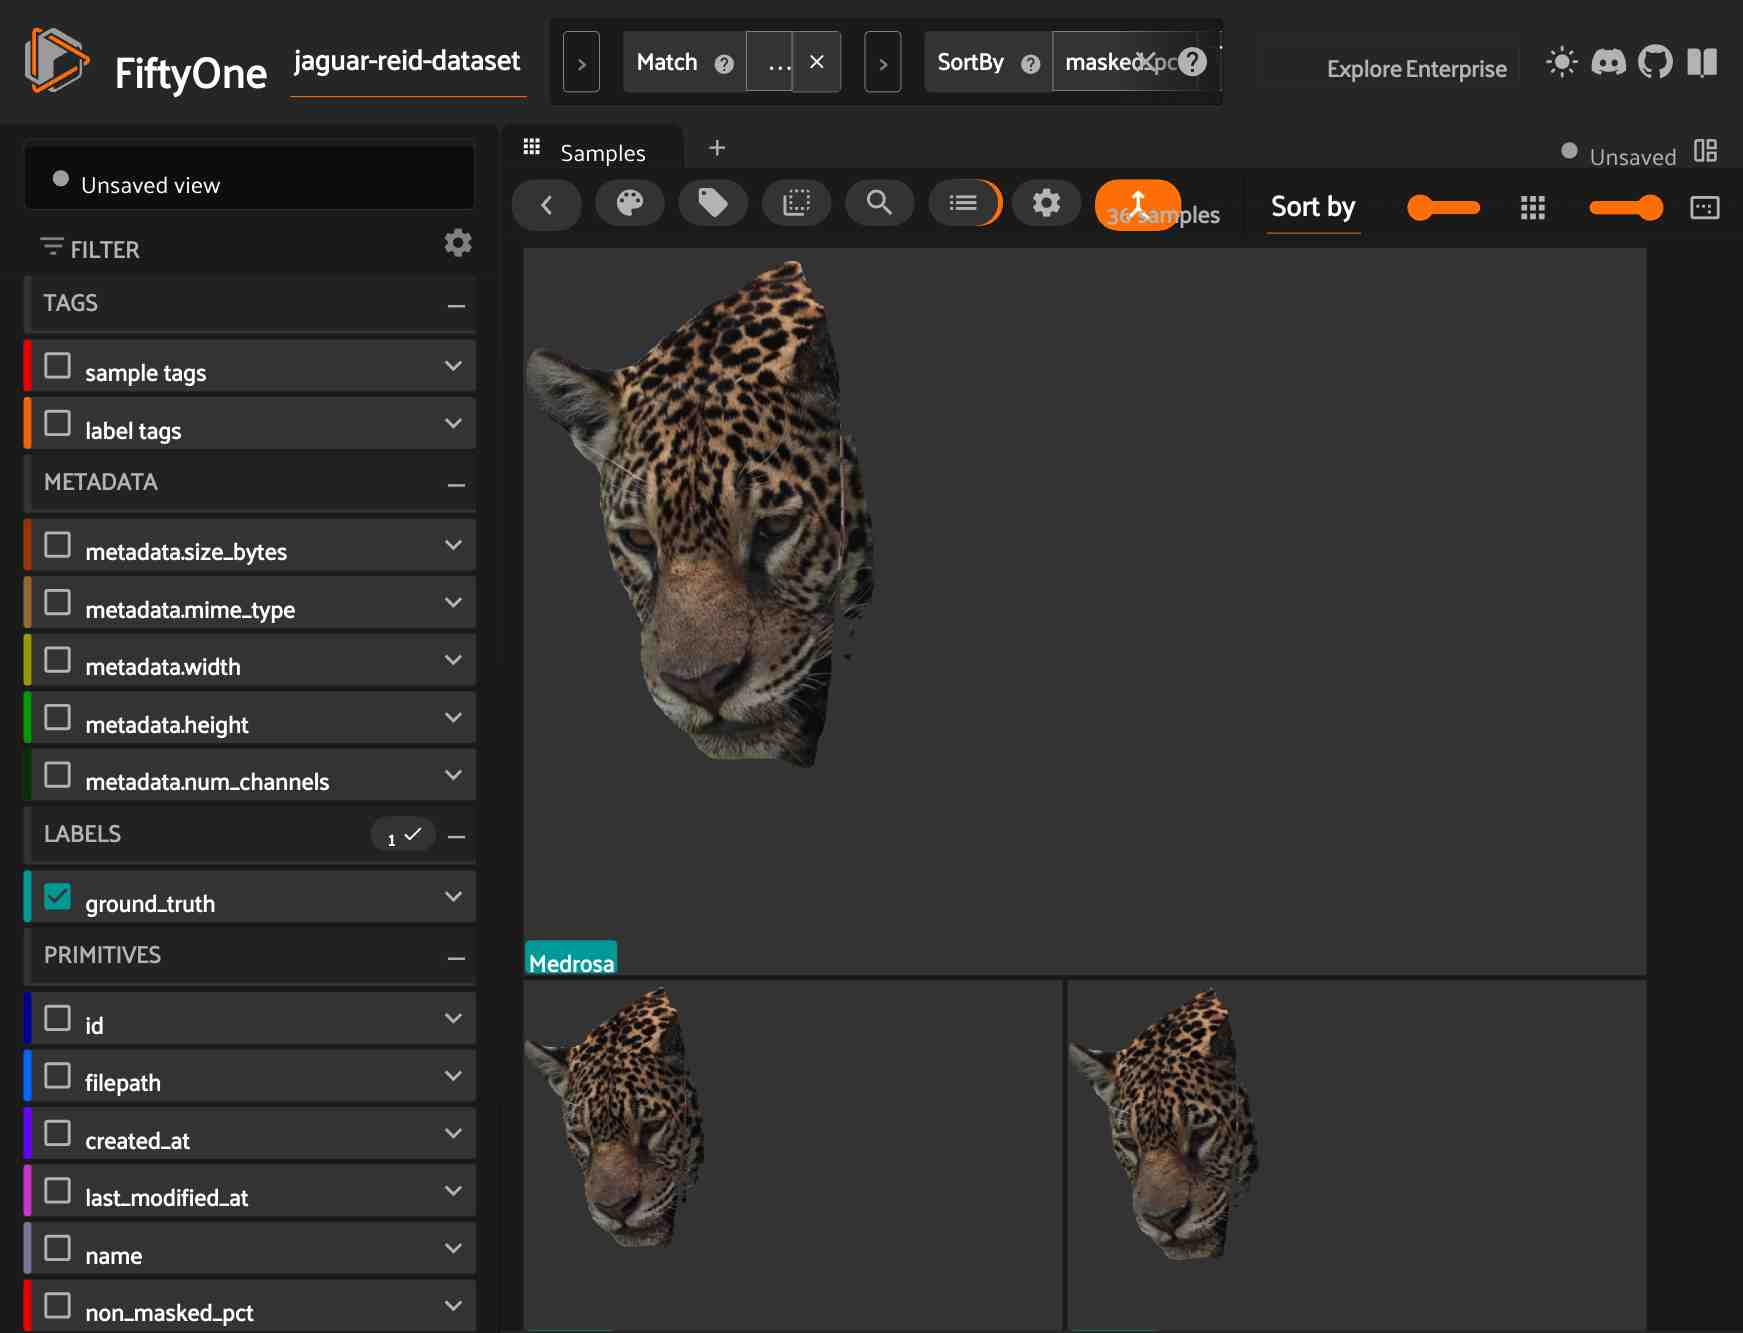

In [8]:
session = fo.launch_app(dataset)

## Image Quality Analysis

This section analyzes the general quality of the images, including properties such as image resolution and the number of non-masked pixels.

First, we examine the distribution of image widths and heights across the dataset.


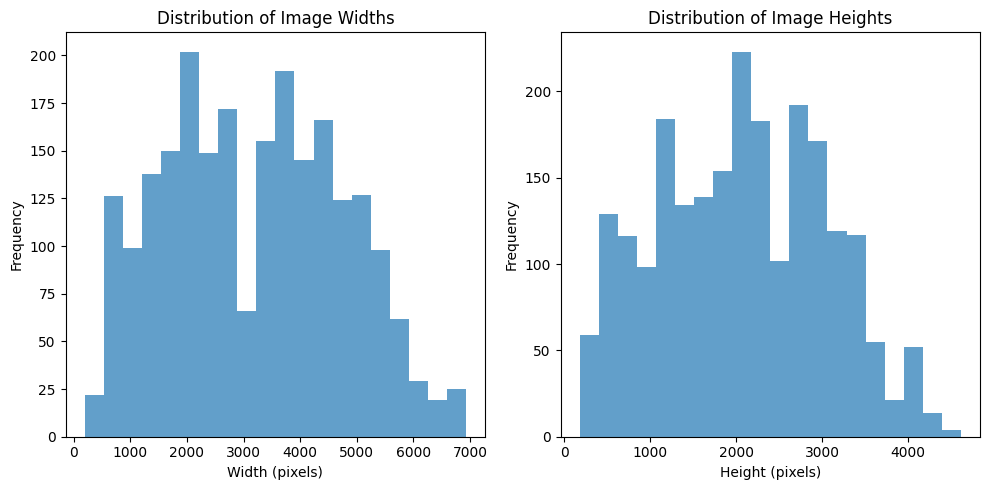

In [9]:
widths = dataset.values("metadata.width")
heights = dataset.values("metadata.height")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(widths, bins=20, alpha=0.7)
plt.title("Distribution of Image Widths")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(heights, bins=20, alpha=0.7)
plt.title("Distribution of Image Heights")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "image_dimensions_distribution.png")

wandb.log({"image_dimensions_distribution": wandb.Image(OUTPUT_PATH / "image_dimensions_distribution.png")})

plt.show()

**Dataset Resolution Summary**

- Orientation: The dataset is predominantly landscape-oriented, with widths extending up to ~7,000px and heights capping around ~4,500px.
- Consistency: The distribution is multimodal and high-variance, indicating a diverse collection of high-resolution assets rather than a standardized set.
- Preprocessing: Significant resizing or padding will be required for model training due to the lack of uniform dimensions.

Next, we examine the percentage of masked pixels in each image. This metric indicates how much of the jaguar is actually visible and helps assess whether significant background interventions are required.


In [10]:
recalc_masked_ratios = False

if "non_masked_pct" not in dataset.get_field_schema() or recalc_masked_ratios:
    for sample in tqdm(dataset, desc="Calculating masked ratios"):
        img = cv2.imread(sample.filepath, cv2.IMREAD_UNCHANGED)

        if img.shape[2] != 4:
            continue  # skip non-RGBA

        alpha = img[:, :, 3]

        total = alpha.size
        non_masked = np.count_nonzero(alpha > 0)
        masked = np.count_nonzero(alpha == 0)

        sample["non_masked_pct"] = non_masked / total
        sample["masked_pct"] = masked / total

        sample.save()

In [11]:
non_masked_mean = dataset.mean("non_masked_pct")
non_masked_std = dataset.std("non_masked_pct")
non_masked_min = dataset.min("non_masked_pct")
non_masked_max = dataset.max("non_masked_pct")

print("Non-masked stats:")
print("     Mean:", non_masked_mean)
print("     Std:", non_masked_std)
print("     Min:", non_masked_min)
print("     Max:", non_masked_max)

wandb.log({
    "non_masked_pct_mean": non_masked_mean,
    "non_masked_pct_std": non_masked_std,
    "non_masked_pct_min": non_masked_min,
    "non_masked_pct_max": non_masked_max,
})

Non-masked stats:
     Mean: 0.45968234099001526
     Std: 0.11787550285203789
     Min: 0.12843986909430682
     Max: 0.9288560529238495


The statistics indicate that the **foreground (jaguar) occupies a relatively small portion of the images**. On average, the jaguar represents **45.97% of the image area**, with a **standard deviation of 11.79%**, meaning the visible jaguar size varies moderately across the dataset. The foreground coverage ranges from **12.84% (very small jaguar region)** to **92.89% (almost the entire image)**.

This spread shows that some images are tightly focused on the animal, while others include large amounts of surrounding environment. Such variation can affect re-identification performance because images with very small foreground regions provide less identity-relevant information (e.g., coat pattern details). Ensuring sufficient resolution of the jaguar region or applying cropping/normalization may help the model learn more consistent identity features.

We will test this in a future experiment.

We want to visualize images with a high masked percentage.

Number of samples with >80% masked area: 36



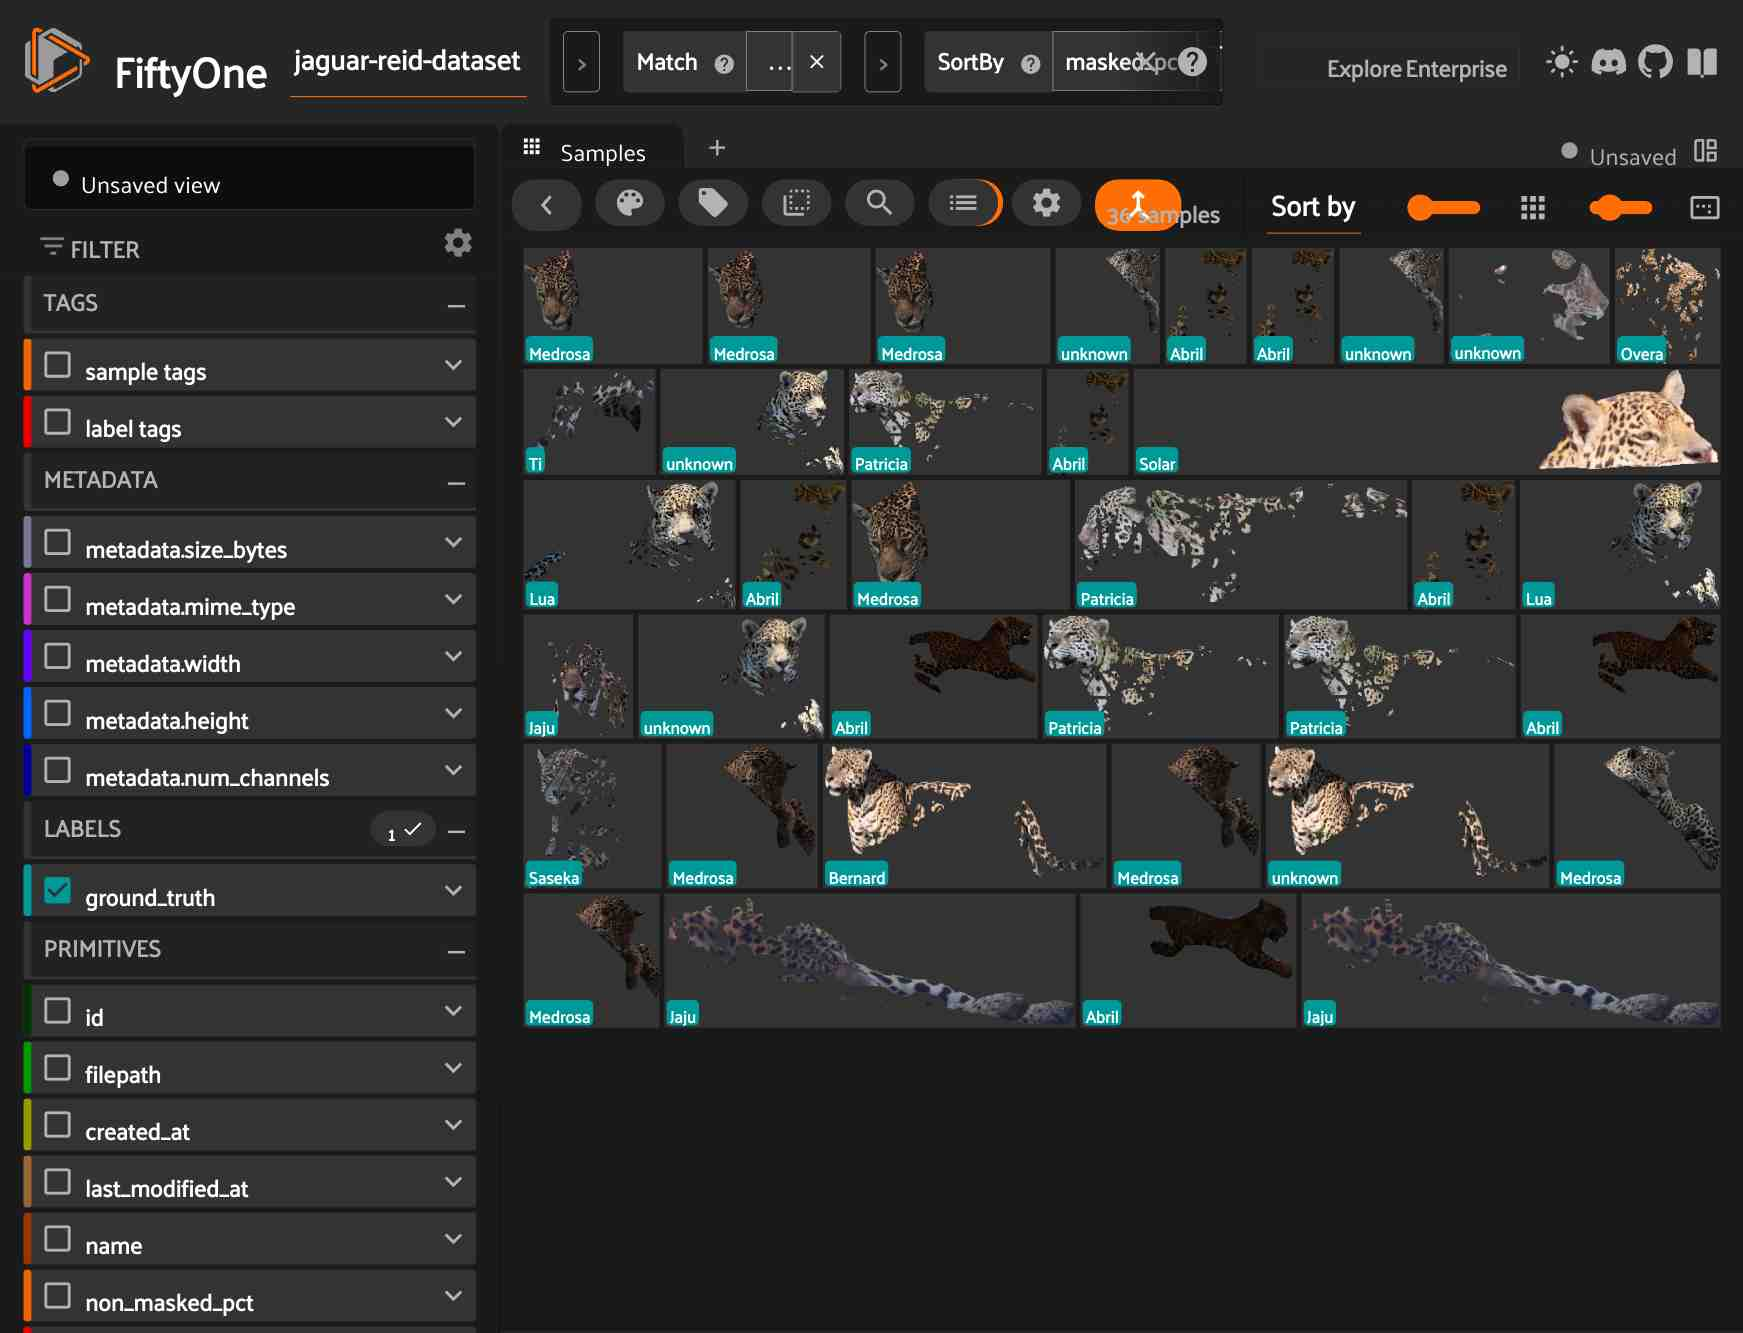

In [12]:
masked_samples_view = dataset.match(
    F("masked_pct") > 0.8
)

print(f"Number of samples with >80% masked area: {len(masked_samples_view)}")
wandb.log({"num_masked_samples_above_80%": len(masked_samples_view)})

session.view = masked_samples_view.sort_by("masked_pct", reverse=True)


## Identity Distribution

In this section, we analyze the distribution of jaguar identities across the dataset.

First, we compute the number of samples in the training and test sets.


In [13]:
tag_counts = dataset.count_sample_tags()
print(f"Tag counts: {tag_counts}")

Tag counts: {'train': 1895, 'test': 371}


Class distribution visualization for the training and validation splits.

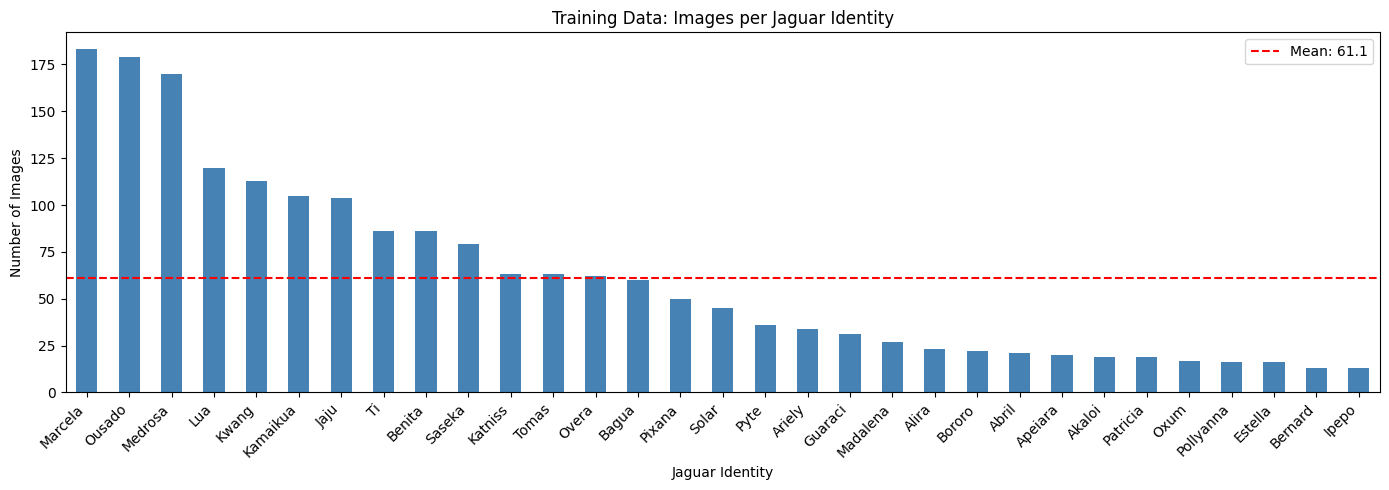

In [14]:
train_view = dataset.match_tags("train")
train_identity_counts = train_view.count_values("ground_truth.label")
train_identity_counts_df = pd.Series(train_identity_counts).sort_values(ascending=False)

num_classes = len(train_identity_counts_df)

fig, ax = plt.subplots(figsize=(14, 5))
train_identity_counts_df.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Training Data: Images per Jaguar Identity')
ax.axhline(
    y=train_identity_counts_df.mean(),
    color='red',
    linestyle='--',
    label=f'Mean: {train_identity_counts_df.mean():.1f}'
)
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

wandb.log({"identity_distribution_full": wandb.Image(fig)})

plt.show()

In [15]:
total = train_identity_counts_df.sum()
gini_index = 1 - np.sum((train_identity_counts_df / total) ** 2)
print(f"Gini Index for Identity Distribution: {gini_index:.4f}")

wandb.log({"gini_index_identity_distribution": gini_index})

Gini Index for Identity Distribution: 0.9465


**Jaguar Identity Distribution Summary**

The training dataset exhibits a highly skewed, long-tailed distribution, characterized by a Gini Index of 0.9465. This value indicates extreme inequality in the number of images per individual.

- Extreme Class Imbalance: A small group of jaguars (Marcela, Ousado, and Medrosa) dominate the dataset with nearly 175–185 images each.
- The Long Tail: The majority of the 30+ identified individuals fall significantly below the mean of 61.1 images.
- Data Scarcity: At the far end of the distribution, individuals like Ipepo and Bernard have fewer than 15 images available for training.
- Model Impact: With such a high Gini Index, a standard model may struggle to generalize for infrequent identities, likely showing high accuracy for top-tier individuals but poor recall for those in the long tail.

Future experiments will evaluate the effect of dataset balancing on model performance.

## Embedding Analysis

This section explores the embedding space generated by the **MegaDescriptor** model. We selected this model because it was used in the baseline notebook and has shown promise due to its training on wildlife re-identification tasks.


In [16]:
device = get_device()
print(f"Using device: {device}")

num_workers = min(8, os.cpu_count())
print(f"Using num_workers={num_workers}")

Using CPU
Using device: cpu
Using num_workers=8


The model is loaded using **timm**, and the preprocessing pipeline is also provided by **timm**.

In [ ]:
# Load MegaDescriptor model
print("Loading MegaDescriptor-L-384 model...")
megadescriptor = timm.create_model(
    config["megadescriptor_model"],
    pretrained=True
)
megadescriptor.eval()
megadescriptor.to(device)
if device == "cuda":
    megadescriptor.compile()

# Get the default data configuration for the model and create the preprocessing transform
megadescriptor_config = resolve_data_config({}, model=megadescriptor)
megadescriptor_preprocess = create_transform(**megadescriptor_config, is_training=False)

megadescriptor_num_params = sum(p.numel() for p in megadescriptor.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {megadescriptor_num_params:,}")
print(f"  Preprocessing: {megadescriptor_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = megadescriptor_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = megadescriptor(dummy_input)
    megadescriptor_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {megadescriptor_dim}")

wandb.log({
    "megadescriptor_num_params": megadescriptor_num_params,
    "megadescriptor_embedding_dim": megadescriptor_dim,
    "megadescriptor_input_size": megadescriptor_config["input_size"],
    "megadescriptor_preprocessing": str(megadescriptor_config),
})

Loading MegaDescriptor-L-384 model...
Model loaded successfully
  Parameters: 195,198,516
  Preprocessing: {'input_size': [3, 384, 384], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 0.9, 'crop_mode': 'center'}
  Embedding dimension: 1536


Set up a dataloader to efficiently recompute embeddings when necessary.


In [19]:
filepaths = dataset.values("filepath")

image_dataset = ImageDataset(
    filepaths,
    preprocess_fn=megadescriptor_preprocess
)

image_loader = DataLoader(
    image_dataset,
    batch_size=32,
    num_workers=num_workers,
    shuffle=False,
    pin_memory=True,
)

Create embedding field for dataset if not already exist. We recompute the embeddings if necessary. We use a shared path for all notebooks to save compute power.

In [20]:
embedding_in_schema = "embedding" in dataset.get_field_schema()

if embedding_in_schema:
    print("Embedding field already exists in dataset schema.")
    print("Skipping embedding extraction.")

    megadescriptor_embeddings = np.array(dataset.values("embedding"))
else:
    print("Embedding field not found in dataset schema. Adding embeddings to dataset...")
    
    megadescriptor_cache_path = OUTPUT_PATH_SHARED / "megadescriptor_embeddings.npz"
    filenames = [path.split("/")[-1] for path in filepaths]

    # Load or compute embeddings
    megadescriptor_embeddings = get_embeddings(
        model=megadescriptor,
        cache_path=megadescriptor_cache_path,
        data_loader=image_loader,
        filenames=filenames,
        device=device
    )
        
    # Add embeddings to dataset
    for sample, embedding in zip(dataset, megadescriptor_embeddings):
        sample["embedding"] = embedding
        sample.save()

    print("Embeddings added to dataset successfully.")

print(f"MegaDescriptor embeddings shape: {megadescriptor_embeddings.shape}")

Embedding field not found in dataset schema. Adding embeddings to dataset...
Extracting embeddings for 71 images...


Extracting embeddings:   0%|          | 0/71 [00:00<?, ?it/s]/home/matti/Git/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Extracting embeddings: 100%|██████████| 71/71 [30:29<00:00, 25.76s/it]


Saved embeddings cache to /home/matti/Git/Kaggle-Competition-Jaguar-Re-identification/output/shared/megadescriptor_embeddings.npz
Embeddings shape: (2266, 1536)
Embeddings added to dataset successfully.
MegaDescriptor embeddings shape: (2266, 1536)


We visualize the baseline **MegaDescriptor** embeddings using **Multidimensional Scaling (MDS)**.


/home/matti/Git/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/matti/Git/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/matti/Git/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


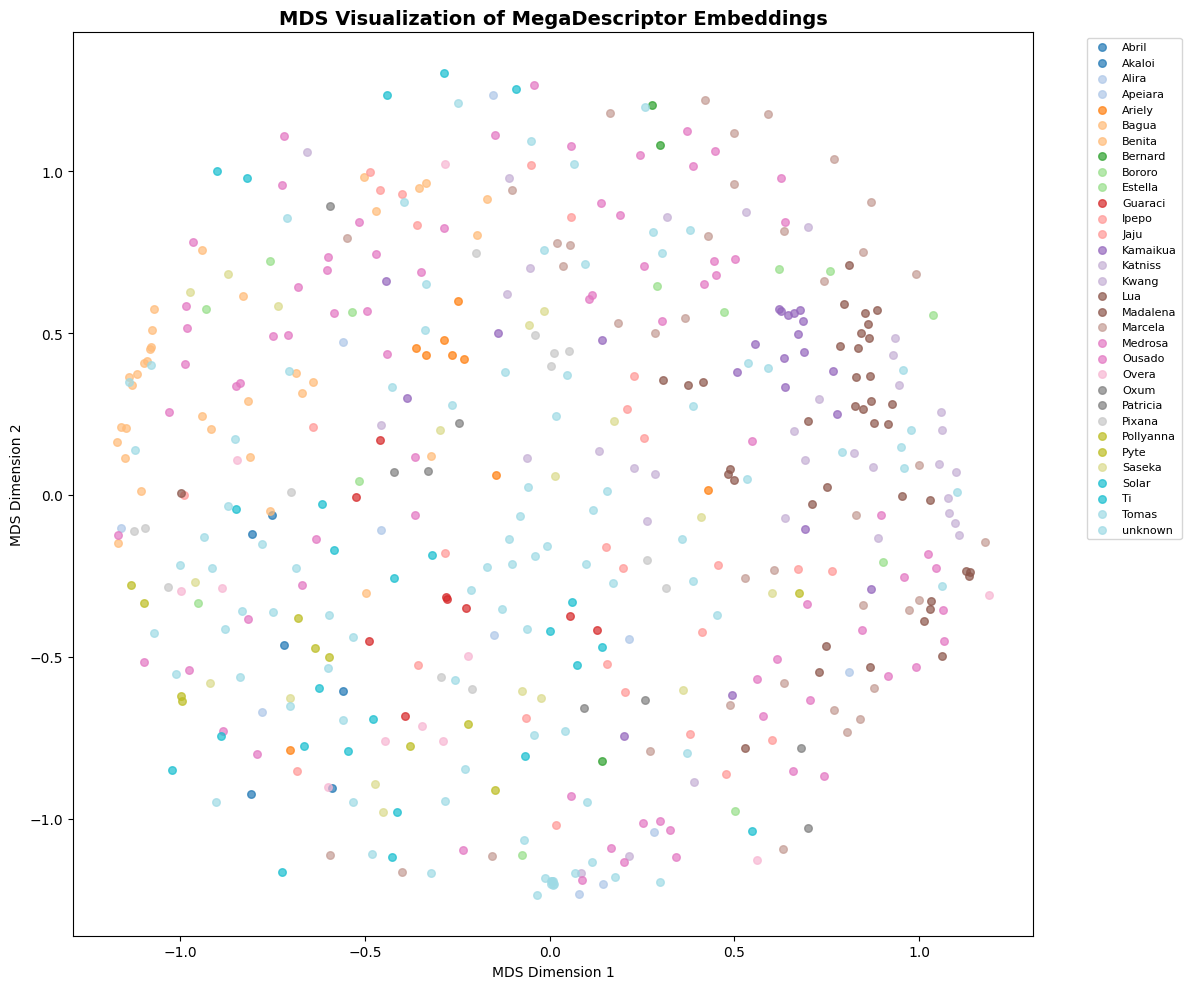

In [21]:
labels = np.array(dataset.values("ground_truth.label"))

mds_fig = visualize_embeddings_mds(
    megadescriptor_embeddings,
    labels,
    "MDS Visualization of MegaDescriptor Embeddings",
    config["seed"]
)

wandb.log({"megadescriptor_embeddings_mds": wandb.Image(mds_fig)})

plt.show()

For dataset inspection, we compute image similarities using **FiftyOne**.

In [22]:
similarity_brain_key = "cosine_similarity_index"
if similarity_brain_key in dataset.list_brain_runs():
    print(f"Similarity brain key '{similarity_brain_key}' already exists in dataset.")
    print("Skipping similarity computation.")
else:
    print(f"Computing similarity for brain key '{similarity_brain_key}'...")

    fob.compute_similarity(
        dataset,
        embeddings="embedding",
        brain_key="cosine_similarity_index",
        backend="sklearn",
        metric="cosine"
    )

Computing similarity for brain key 'cosine_similarity_index'...


We generate PCA and UMAP visualizations to explore the dataset's structure in lower-dimensional space.

Generating visualization...
Generating visualization...
UMAP( verbose=True)
Sun Mar  8 20:18:06 2026 Construct fuzzy simplicial set
Sun Mar  8 20:18:09 2026 Finding Nearest Neighbors
Sun Mar  8 20:18:12 2026 Finished Nearest Neighbor Search
Sun Mar  8 20:18:14 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sun Mar  8 20:18:15 2026 Finished embedding


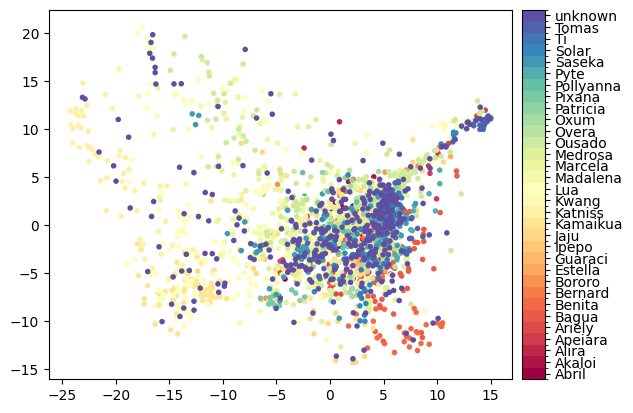

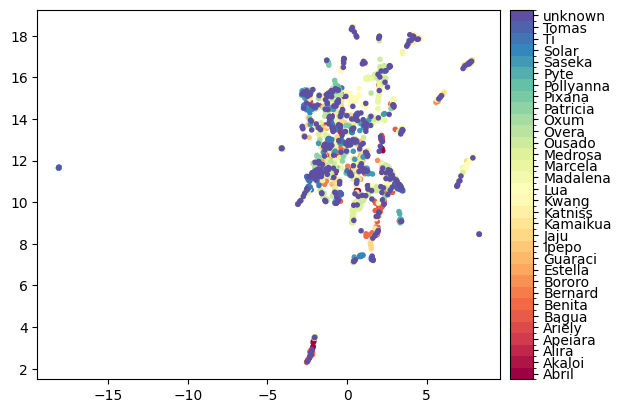

In [23]:
pca_visualization = fob.compute_visualization(
    dataset,
    method="pca",
    embeddings="embedding",
    num_dims=2,
    brain_key="pca_visualization_embedding"
)

plot = pca_visualization.visualize(labels="ground_truth.label", backend="matplotlib")
plot.save(CHECKPOINT_PATH / "megadescriptor_embeddings_pca.png")
wandb.log({"megadescriptor_embeddings_pca": wandb.Image(CHECKPOINT_PATH / "megadescriptor_embeddings_pca.png")})

umap_visualization = fob.compute_visualization(
    dataset,
    method="umap",
    embeddings="embedding",
    num_dims=2,
    brain_key="umap_visualization_embedding"
)

plot = umap_visualization.visualize(labels="ground_truth.label", backend="matplotlib")
plot.save(CHECKPOINT_PATH / "megadescriptor_embeddings_umap.png")
wandb.log({"megadescriptor_embeddings_umap": wandb.Image(CHECKPOINT_PATH / "megadescriptor_embeddings_umap.png")})

We compute **uniqueness** and **representativeness** of the images:
- **Uniqueness:** Measures how distinct each image is compared to all others in the dataset.
- **Representativeness:** Assesses how well each image reflects the overall distribution of the dataset.


In [24]:
fob.compute_uniqueness(
    dataset,
    embeddings="embedding"
)

uniqueness_mean = dataset.mean("uniqueness")
uniqueness_std = dataset.std("uniqueness")
uniqueness_min = dataset.min("uniqueness")
uniqueness_max = dataset.max("uniqueness")

print(f"Uniqueness stats:")
print(f"  Mean: {uniqueness_mean:.4f}")
print(f"  Std: {uniqueness_std:.4f}")
print(f"  Min: {uniqueness_min:.4f}")
print(f"  Max: {uniqueness_max:.4f}")

wandb.log({
    "uniqueness_mean": uniqueness_mean,
    "uniqueness_std": uniqueness_std,
    "uniqueness_min": uniqueness_min,
    "uniqueness_max": uniqueness_max,
})

Computing uniqueness...
Uniqueness computation complete
Uniqueness stats:
  Mean: 0.2966
  Std: 0.2365
  Min: 0.0019
  Max: 1.0000


In [25]:
fob.compute_representativeness(
    dataset,
    embeddings="embedding"
)

representativeness_mean = dataset.mean("representativeness")
representativeness_std = dataset.std("representativeness")
representativeness_min = dataset.min("representativeness")
representativeness_max = dataset.max("representativeness")

print(f"Representativeness stats:")
print(f"  Mean: {representativeness_mean:.4f}")
print(f"  Std: {representativeness_std:.4f}")
print(f"  Min: {representativeness_min:.4f}")
print(f"  Max: {representativeness_max:.4f}")

wandb.log({
    "representativeness_mean": representativeness_mean,
    "representativeness_std": representativeness_std,
    "representativeness_min": representativeness_min,
    "representativeness_max": representativeness_max,
})

Computing representativeness...
Computing clusters for 2266 embeddings; this may take awhile...
Representativeness computation complete
Representativeness stats:
  Mean: 0.6328
  Std: 0.1386
  Min: 0.3055
  Max: 1.0000



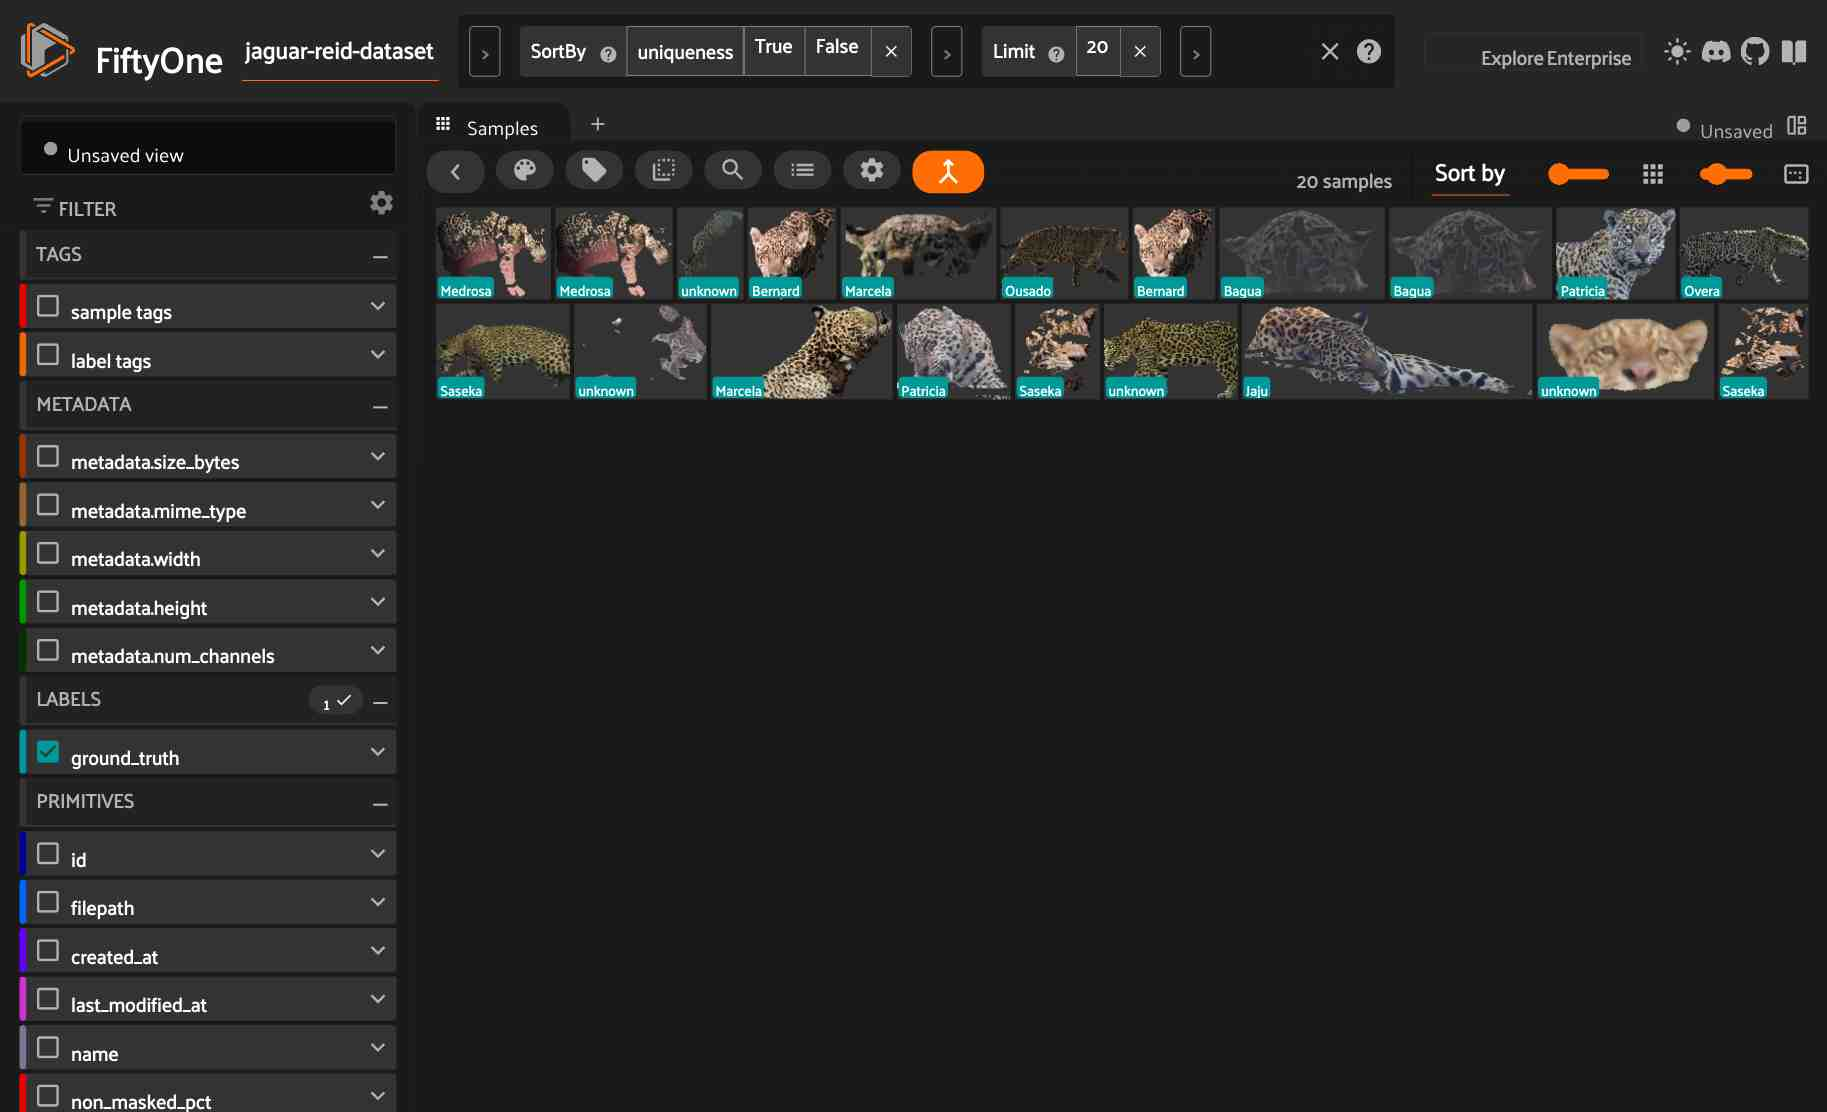

In [37]:
# Select most unique samples
most_unique_view = dataset.sort_by("uniqueness", reverse=True).limit(20)
session.view = most_unique_view


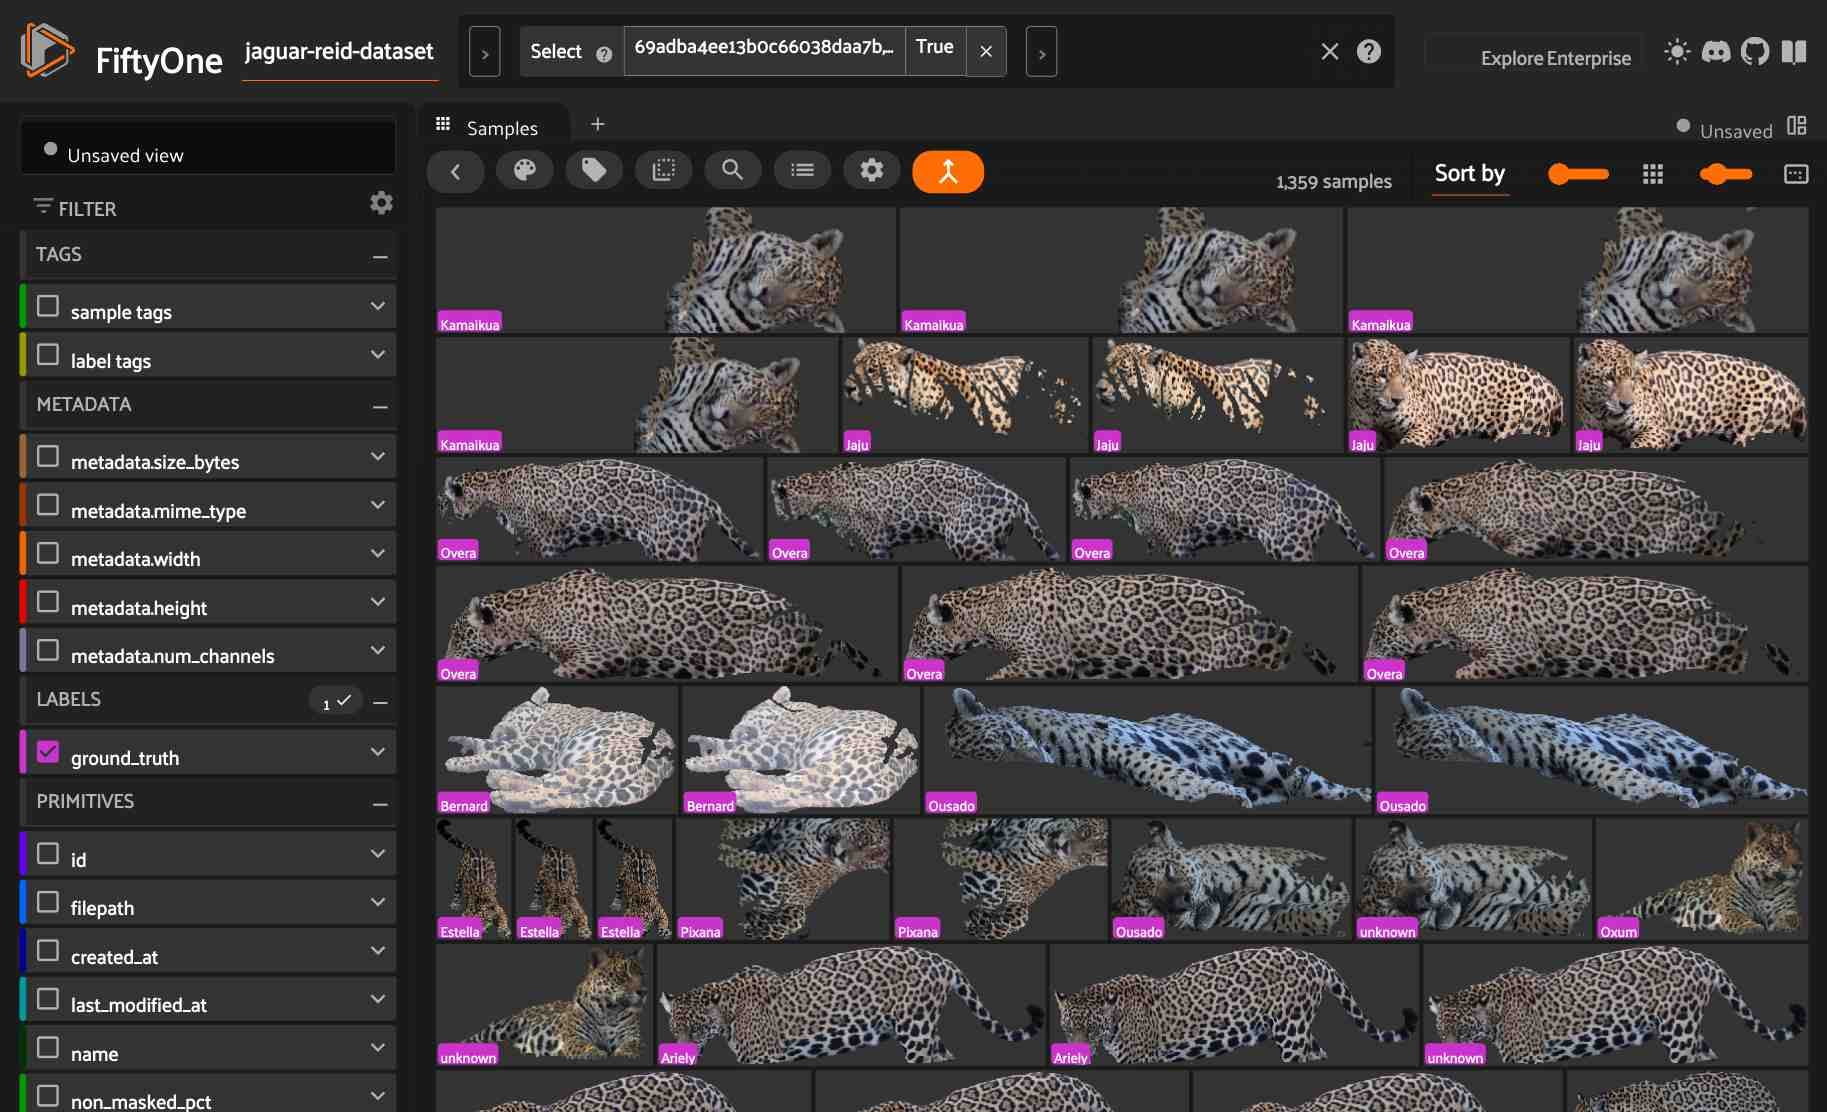

In [27]:
# Select most representative samples
most_representative_view = dataset.sort_by("representativeness", reverse=True).limit(20)
session.view = most_representative_view

## Duplicate Analysis

Next, we check the dataset for duplicates. First, we analyze **exact duplicates** using FiftyOne's built-in functionality.


In [28]:
exact_duplicates = fob.compute_exact_duplicates(
    dataset,
)
print(exact_duplicates)

Computing filehashes...
 100% |███████████████| 2266/2266 [12.7s elapsed, 0s remaining, 192.6 samples/s]      
{}


No exact duplicates were detected. In the next step, we search for **near-duplicates** using the image embeddings. A threshold of 0.1 is used, since even visually different images tend to have very similar embeddings in this space.



In [29]:
near_duplicates = fob.compute_near_duplicates(
    dataset,
    embeddings="embedding",
    threshold=0.1,
)

Computing duplicate samples...
Duplicates computation complete


In [ ]:
near_duplicates_view = near_duplicates.duplicates_view(
    type_field="duplicate_type"
)

print(f"Near duplicates view: {len(near_duplicates_view)}")

session.view = near_duplicates_view

Near duplicates view: 1359


We observed many near-duplicate images that appear almost identical. Interestingly, some test images are duplicates of training images. While this could artificially improve the mAP score in a final submission, it may reduce the generalizability of the model.

Although we will not remove duplicates, it is still informative to examine how identity distributions would change if duplicates were excluded.


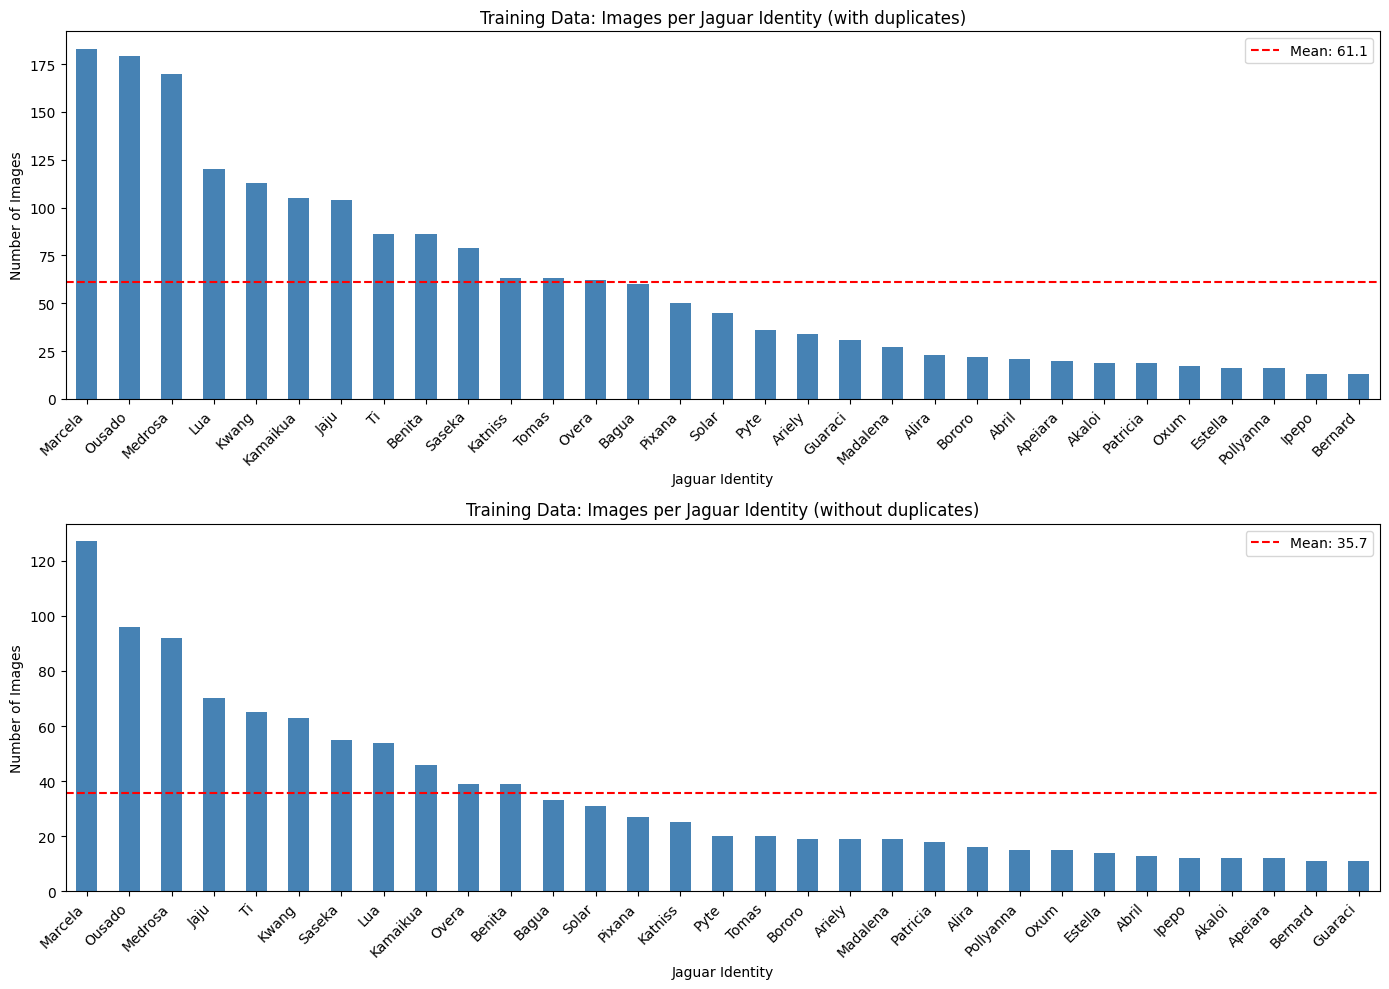

In [31]:
train_view = dataset.match_tags("train")
train_identity_counts = train_view.count_values("ground_truth.label")
train_identity_counts_df = pd.Series(train_identity_counts).sort_values(ascending=False)

train_view_wduplicates = train_view.match(F("duplicate_type") != "duplicate")
train_identity_counts_wduplicates = train_view_wduplicates.count_values("ground_truth.label")
train_identity_counts_df_wduplicates = pd.Series(train_identity_counts_wduplicates).sort_values(ascending=False)

num_classes = len(train_identity_counts_df)

fig = plt.figure(figsize=(14, 10))

ax1 = plt.subplot(2, 1, 1)
train_identity_counts_df.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_xlabel('Jaguar Identity')
ax1.set_ylabel('Number of Images')
ax1.set_title('Training Data: Images per Jaguar Identity (with duplicates)')
ax1.axhline(
    y=train_identity_counts_df.mean(),
    color='red',
    linestyle='--',
    label=f'Mean: {train_identity_counts_df.mean():.1f}'
)
ax1.legend()
plt.xticks(rotation=45, ha='right')

ax2 = plt.subplot(2, 1, 2)
train_identity_counts_df_wduplicates.plot(kind='bar', ax=ax2, color='steelblue')
ax2.set_xlabel('Jaguar Identity')
ax2.set_ylabel('Number of Images')
ax2.set_title('Training Data: Images per Jaguar Identity (without duplicates)')
ax2.axhline(
    y=train_identity_counts_df_wduplicates.mean(),
    color='red',
    linestyle='--',
    label=f'Mean: {train_identity_counts_df_wduplicates.mean():.1f}'
)
ax2.legend()
plt.xticks(rotation=45, ha='right')

plt.tight_layout()

wandb.log({"identity_distribution_without_duplicates": wandb.Image(fig)})

plt.show()

In [32]:
total = train_identity_counts_df.sum()
gini_index = 1 - np.sum((train_identity_counts_df / total) ** 2)
print(f"Gini Index for Identity Distribution: {gini_index:.4f}")

total = train_identity_counts_df_wduplicates.sum()
gini_index_wduplicates = 1 - np.sum((train_identity_counts_df_wduplicates / total) ** 2)
print(f"Gini Index for Identity Distribution (without duplicates): {gini_index_wduplicates:.4f}")

Gini Index for Identity Distribution: 0.9465
Gini Index for Identity Distribution (without duplicates): 0.9468


**Duplicate Removal Analysis**

The removal of duplicates significantly reduces the overall dataset size and alters the distribution of images per jaguar identity.

- Drastic Reduction in Sample Size: The average number of images per identity drops from a mean of 61.1 to 35.7.
- Persistent Class Imbalance: Despite the removal, the distribution remains highly skewed. The "long tail" persists, with many individuals now represented by fewer than 10 unique images.
- Reordered Rankings: The relative frequency of certain individuals changed.
- Gini Index: Remains largely unchanged, indicating that class imbalance persists.

The duplicated files are exported for further analysis and saved in a new CSV file.


In [33]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv")
train_df.set_index("filename", inplace=True)

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


In [34]:
# set new column in df with duplicate labels
train_df["duplicate_id"] = None

last_nearest = None
duplicate_id = 0
for sample in near_duplicates_view:
    if sample["duplicate_type"] == "nearest":
        duplicate_id += 1

    if sample.name in train_df.index:
        train_df.loc[sample.name, "duplicate_id"] = duplicate_id

print(f"Total duplicates found: {duplicate_id}")
train_df.to_csv(DATA_PATH / "train_with_duplicates.csv")
train_df.head()

Total duplicates found: 450


,ground_truth,duplicate_id
filename,,
train_0001.png,Abril,168
train_0002.png,Abril,168
train_0003.png,Abril,None
train_0004.png,Akaloi,None
train_0005.png,Akaloi,None


## Export

Export the created dataset in FiftyOne format. We do not export the files to save memory.

In [35]:
export_dir = DATA_PATH / dataset_name
export_dir.mkdir(parents=True, exist_ok=True)

print(f"Exporting dataset '{dataset_name}' to: {export_dir}")

dataset.export(
    export_dir=str(export_dir),
    dataset_type=fo.types.FiftyOneDataset,  # preserves groups, modalities, metadata, labels, etc.
    overwrite=True,
    progress=True,
    export_media=False,
)

print("Export finished.")

Exporting dataset 'jaguar-reid-dataset' to: /home/matti/Git/Kaggle-Competition-Jaguar-Re-identification/data/jaguar-reid-dataset
Exporting samples...
 100% |██████████████████| 2266/2266 [140.7ms elapsed, 0s remaining, 16.1K docs/s]     
Export finished.


In [36]:
wandb.finish()

gini_index_identity_distribution,▁
megadescriptor_embedding_dim,▁
megadescriptor_num_params,▁
non_masked_pct_max,▁
non_masked_pct_mean,▁
non_masked_pct_min,▁
non_masked_pct_std,▁
num_masked_samples_above_80%,▁
representativeness_max,▁
representativeness_mean,▁
+6,...
